# Práctico 5 - Ejercicio 3

Clasificación sobre Breast Cancer Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

# Carga del dataset
cancer = load_breast_cancer()
X = cancer['data']
y = cancer['target']

Los datos vienen con un formato especial, similar a un diccionario.

Es posible juntar X e y en un array para armar un `DataFrame`

In [5]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [3]:
np.hstack([X, y.reshape(-1, 1)])

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 4.601e-01, 1.189e-01,
        0.000e+00],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 2.750e-01, 8.902e-02,
        0.000e+00],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 3.613e-01, 8.758e-02,
        0.000e+00],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 2.218e-01, 7.820e-02,
        0.000e+00],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 4.087e-01, 1.240e-01,
        0.000e+00],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 2.871e-01, 7.039e-02,
        1.000e+00]], shape=(569, 31))

In [6]:
cancer['feature_names']

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [ ]:
cancer_df = pd.DataFrame(
    data=np.hstack([X, y.reshape(-1, 1)]),
    columns=list(cancer['feature_names']) + ['target']
)
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0.0


## Identificación de Datos

In [7]:
n_ejemplos, n_atributos = X.shape
n_clases = len(cancer.target_names)
print(f"(a) Clases: {cancer.target_names} ({n_clases})")
print(f"    Atributos: {n_atributos}")
print(f"    Total de ejemplos: {n_ejemplos}")

(a) Clases: ['malignant' 'benign'] (2)
    Atributos: 30
    Total de ejemplos: 569


## PCA sin escalado

Si se realiza PCA sin hacer escalado, van a encontrar que hay muy poca varianza explicada por direcciones que no sean la principal. Esto se debe a diferencias en las magnitudes de los valores de cada feature/característica

In [8]:
first_pca = PCA()
X_old_pca = first_pca.fit_transform(X)
var_explained = first_pca.explained_variance_ratio_

print("\n(c) Fracción de varianza explicada por las primeras 10 componentes:")
for i, v in enumerate(var_explained[:10]):
    print(f"    CP{i+1}: {v:.4f}")

print(f"    Varianza acumulada (10 CP): {np.sum(var_explained[:10]):.4f}")


(c) Fracción de varianza explicada por las primeras 10 componentes:
    CP1: 0.9820
    CP2: 0.0162
    CP3: 0.0016
    CP4: 0.0001
    CP5: 0.0001
    CP6: 0.0000
    CP7: 0.0000
    CP8: 0.0000
    CP9: 0.0000
    CP10: 0.0000
    Varianza acumulada (10 CP): 1.0000


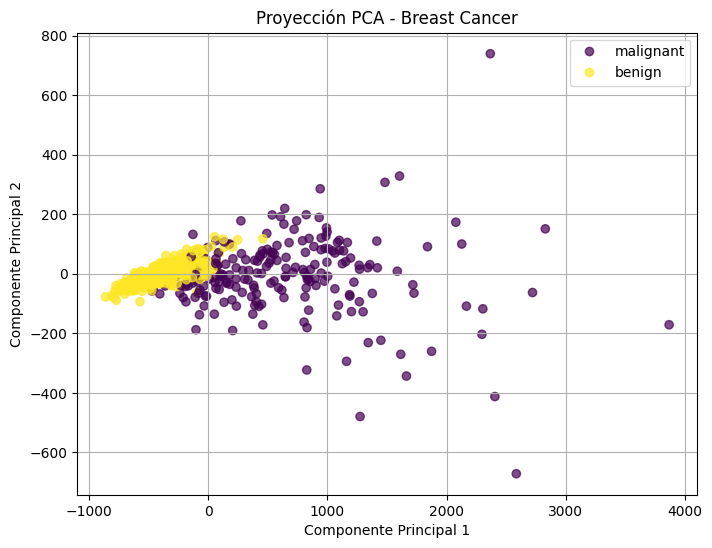

In [9]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_old_pca[:, 0], X_old_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección PCA - Breast Cancer')
plt.legend(handles=scatter.legend_elements()[0], labels=list(cancer.target_names))
plt.grid(True)
plt.show()

## Escalado y PCA

Escalemos y visualicemos la matriz de covarianza

<Axes: >

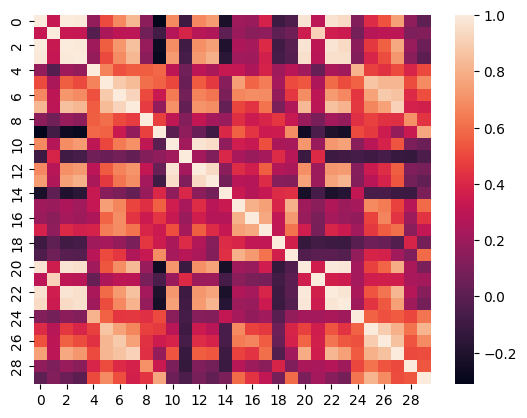

In [10]:
# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
sns.heatmap(np.cov(X_scaled, rowvar=False))

Apliquemos PCA nuevamente y veamos qué ocurre con las varianzas explicadas

In [11]:
pca_scaled = PCA()
X_pca = pca_scaled.fit_transform(X_scaled)
var_explained = pca_scaled.explained_variance_ratio_

print("\n(c) Fracción de varianza explicada por las primeras 10 componentes:")
for i, v in enumerate(var_explained[:10]):
    print(f"    CP{i+1}: {v:.4f}")

print(f"    Varianza acumulada (10 CP): {np.sum(var_explained[:10]):.4f}")


(c) Fracción de varianza explicada por las primeras 10 componentes:
    CP1: 0.4427
    CP2: 0.1897
    CP3: 0.0939
    CP4: 0.0660
    CP5: 0.0550
    CP6: 0.0402
    CP7: 0.0225
    CP8: 0.0159
    CP9: 0.0139
    CP10: 0.0117
    Varianza acumulada (10 CP): 0.9516


Primeras dos componentes

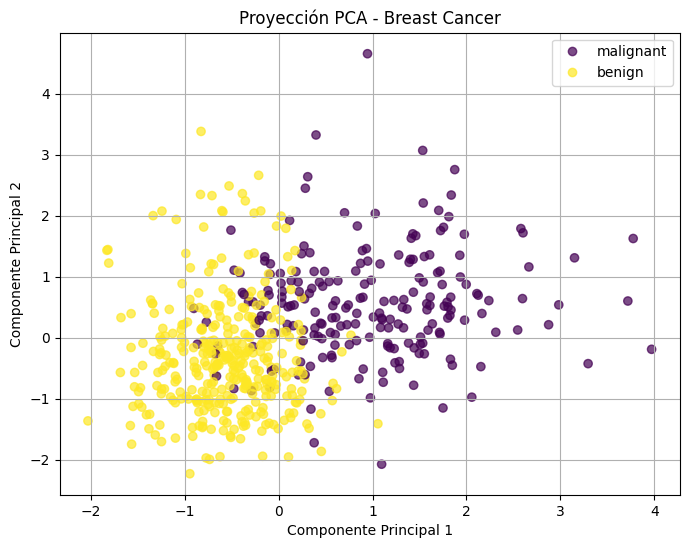

In [12]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección PCA - Breast Cancer')
plt.legend(handles=scatter.legend_elements()[0], labels=list(cancer.target_names))
plt.grid(True)
plt.show()

## Entrenemos un modelo de clasificación
Utilizando todas las variables

In [13]:
naive_bayes = GaussianNB()
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25) 
naive_bayes.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [14]:
print(classification_report(naive_bayes.predict(X_test), y_test))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        58
           1       0.95      0.95      0.95        85

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



Usando sólo las primeras 3 direcciones principales, resultando en un modelo mucho más "barato" (sólo 3 features)

In [15]:
pca_naive = GaussianNB()
X_train, X_test, y_train, y_test = train_test_split(X_scaled[:, :3], y, test_size=0.25)
pca_naive.fit(X_train, y_train)
print(classification_report(pca_naive.predict(X_test), y_test))

              precision    recall  f1-score   support

           0       0.73      0.87      0.79        53
           1       0.91      0.81      0.86        90

    accuracy                           0.83       143
   macro avg       0.82      0.84      0.83       143
weighted avg       0.84      0.83      0.83       143

